In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
from google.colab import files
uploaded=files.upload()

Saving Grading of the students in the exam (IPE101) raw.csv to Grading of the students in the exam (IPE101) raw.csv


In [3]:
df = pd.read_csv('/content/Grading of the students in the exam (IPE101) raw.csv')

In [4]:
df.head()

,Roll,CT-1 (Marks: 20),CT-2 (Marks: 20),CT-3 (Marks: 20),CT-4 (Marks: 20),"Class Test (Total of best 3, Marks: 60)",Attendance (Marks: 15),Observation (Marks: 15),Total (Marks: 90),Exam Mark (105),Exam Mark (105).1,Mark total 300
0,2.0,12.5,15,14,18,47,15,13.5,75.5,45.0,46.5,167.0
1,3.0,9,10,17,11,38,15,13.5,66.5,28.0,44.0,138.5
2,4.0,10,15.5,12.5,6.5,38,15,13.5,66.5,26.5,43.0,136.0
3,5.0,14,14,18,0,46,15,15,76,46.0,44.0,166.0
4,6.0,14.5,15.5,15,15.5,46,15,15,76,26.0,74.5,176.5


In [7]:
df.isnull().sum()

,0
Roll,6
CT-1 (Marks: 20),6
CT-2 (Marks: 20),6
CT-3 (Marks: 20),6
CT-4 (Marks: 20),6
"Class Test (Total of best 3, Marks: 60)",6
Attendance (Marks: 15),6
Observation (Marks: 15),6
Total (Marks: 90),6
Exam Mark (105),9


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 12 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Roll                                     57 non-null     float64
 1   CT-1 (Marks: 20)                         57 non-null     object 
 2   CT-2 (Marks: 20)                         57 non-null     object 
 3   CT-3 (Marks: 20)                         57 non-null     object 
 4   CT-4 (Marks: 20)                         57 non-null     object 
 5   Class Test (Total of best 3, Marks: 60)  57 non-null     object 
 6   Attendance (Marks: 15)                   57 non-null     object 
 7   Observation (Marks: 15)                  57 non-null     object 
 8   Total (Marks: 90)                        57 non-null     object 
 9   Exam Mark (105)                          54 non-null     float64
 10  Exam Mark (105).1                        54 non-null

In [9]:
df.describe()

,Roll,Exam Mark (105),Exam Mark (105).1,Mark total 300
count,57.000000,54.000000,54.000000,54.000000
mean,32.736842,35.972222,57.537037,165.324074
std,18.657176,17.312995,20.441092,35.735290
min,2.000000,3.000000,2.000000,52.000000
25%,16.000000,26.000000,43.250000,139.750000
50%,32.000000,35.500000,59.750000,165.250000
75%,48.000000,48.000000,73.000000,184.125000
max,64.000000,89.000000,97.000000,244.000000


In [10]:
df.shape

(63, 12)

In [16]:
object_cols_to_numeric = [
    'CT-1 (Marks: 20)', 'CT-2 (Marks: 20)', 'CT-3 (Marks: 20)', 'CT-4 (Marks: 20)',
    'Class Test (Total of best 3, Marks: 60)', 'Attendance (Marks: 15)',
    'Observation (Marks: 15)', 'Total (Marks: 90)'
]

for col in object_cols_to_numeric:
    # Convert to numeric, coercing errors to NaN, and then explicitly cast to float
    df[col] = pd.to_numeric(df[col], errors='coerce').astype(float)

# Fill any remaining NaNs with the mean of their respective numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

print(df.isnull().sum())
print(df.info())

Roll                                       0
CT-1 (Marks: 20)                           0
CT-2 (Marks: 20)                           0
CT-3 (Marks: 20)                           0
CT-4 (Marks: 20)                           0
Class Test (Total of best 3, Marks: 60)    0
Attendance (Marks: 15)                     0
Observation (Marks: 15)                    0
Total (Marks: 90)                          0
Exam Mark (105)                            0
Exam Mark (105).1                          0
Mark total 300                             0
Grade                                      0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 13 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Roll                                     63 non-null     float64
 1   CT-1 (Marks: 20)                         63 non-null     float64
 2   CT-2 (Marks: 2

In [18]:
def grade(total):
    if total >= 200:
        return 'A'
    elif total >= 150:
        return 'B'
    else:
        return 'C'

df['Grade'] = df['Mark total 300'].apply(grade)

print(df[['Mark total 300','Grade']].head())

   Mark total 300 Grade
0           167.0     B
1           138.5     C
2           136.0     C
3           166.0     B
4           176.5     B


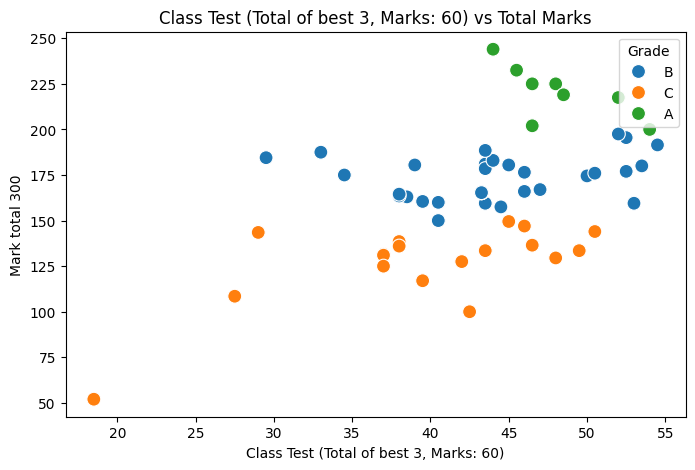

In [38]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Class Test (Total of best 3, Marks: 60)",
    y="Mark total 300",
    hue="Grade",
    s=100
)
plt.title("Class Test (Total of best 3, Marks: 60) vs Total Marks")
plt.show()

In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Grade_Encoded"] = le.fit_transform(df["Grade"])

X = df.drop(
    columns=[
        "Grade",
        "Grade_Encoded"
    ]
)

In [40]:
y = df["Grade_Encoded"]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [43]:
svm_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma="scale"
    ))
])


In [44]:
svm_model.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('svm', SVC(C=10))])

In [48]:
y_pred = svm_model.predict(X_test)

In [51]:
accuracy = accuracy_score(y_test, y_pred)

print("\nSVM Accuracy")
print(round(accuracy*100,2), "%")


SVM Accuracy
92.31 %


In [52]:

sample_student = X.iloc[[0]]

prediction = svm_model.predict(sample_student)

print("\nPredicted Grade:")
print(le.inverse_transform(prediction))


Predicted Grade:
['B']
